# HYDRATION LEVEL PREDICTION USING MACHINE LEARNING

### 1️⃣ Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from imblearn.over_sampling import SMOTE

import pickle
import warnings
warnings.filterwarnings('ignore')

print('✅ Libraries Imported Successfully')

✅ Libraries Imported Successfully


### 2️⃣ Load Dataset


In [2]:
df = pd.read_csv(r"Hydration Level Prediction Dataset.csv")

df.head()

,Age,Gender,Weight(kg),Daily Water Intake (liters),Physical Activity Level,Hydration Level
0,43,Female,93.45,1.64,Moderate,At Risk of Dehydration
1,43,Male,78.15,3.51,Low,Hydrated
2,56,Female,80.82,2.96,Low,Hydrated
3,45,Male,98.33,3.58,Low,Hydrated
4,22,Female,86.86,2.59,High,At Risk of Dehydration


In [3]:
df.shape

(21450, 6)

### 3️⃣ Data Cleaning

#### 🔴 Check Missing Values :

In [4]:
df.isnull().sum()

Age                            0
Gender                         0
Weight(kg)                     0
Daily Water Intake (liters)    0
Physical Activity Level        0
Hydration Level                0
dtype: int64

#### 🔴 Check Duplicate Values :

In [5]:
print('Duplicate Rows:', df.duplicated().sum())
df = df.drop_duplicates()
print('Shape after removing duplicates:', df.shape)

Duplicate Rows: 1450
Shape after removing duplicates: (20000, 6)


### 4️⃣ Exploratory Data Analysis (EDA)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20000 entries, 0 to 21449
Data columns (total 6 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Age                          20000 non-null  int64  
 1   Gender                       20000 non-null  object 
 2   Weight(kg)                   20000 non-null  float64
 3   Daily Water Intake (liters)  20000 non-null  float64
 4   Physical Activity Level      20000 non-null  object 
 5   Hydration Level              20000 non-null  object 
dtypes: float64(2), int64(1), object(3)
memory usage: 1.1+ MB


In [7]:
df.describe()

,Age,Weight(kg),Daily Water Intake (liters)
count,20000.000000,20000.000000,20000.000000
mean,38.413450,72.333901,2.501125
std,12.022938,15.843456,0.870650
min,18.000000,45.000000,1.000000
25%,28.000000,58.570000,1.750000
50%,38.000000,72.270000,2.490000
75%,49.000000,86.052500,3.270000
max,59.000000,100.000000,4.000000


In [8]:
print('Target Variable Distribution:')
print(df['Hydration Level'].value_counts())

Target Variable Distribution:
Hydration Level
At Risk of Dehydration    14000
Hydrated                   6000
Name: count, dtype: int64


### 5️⃣ Distribution Graphs

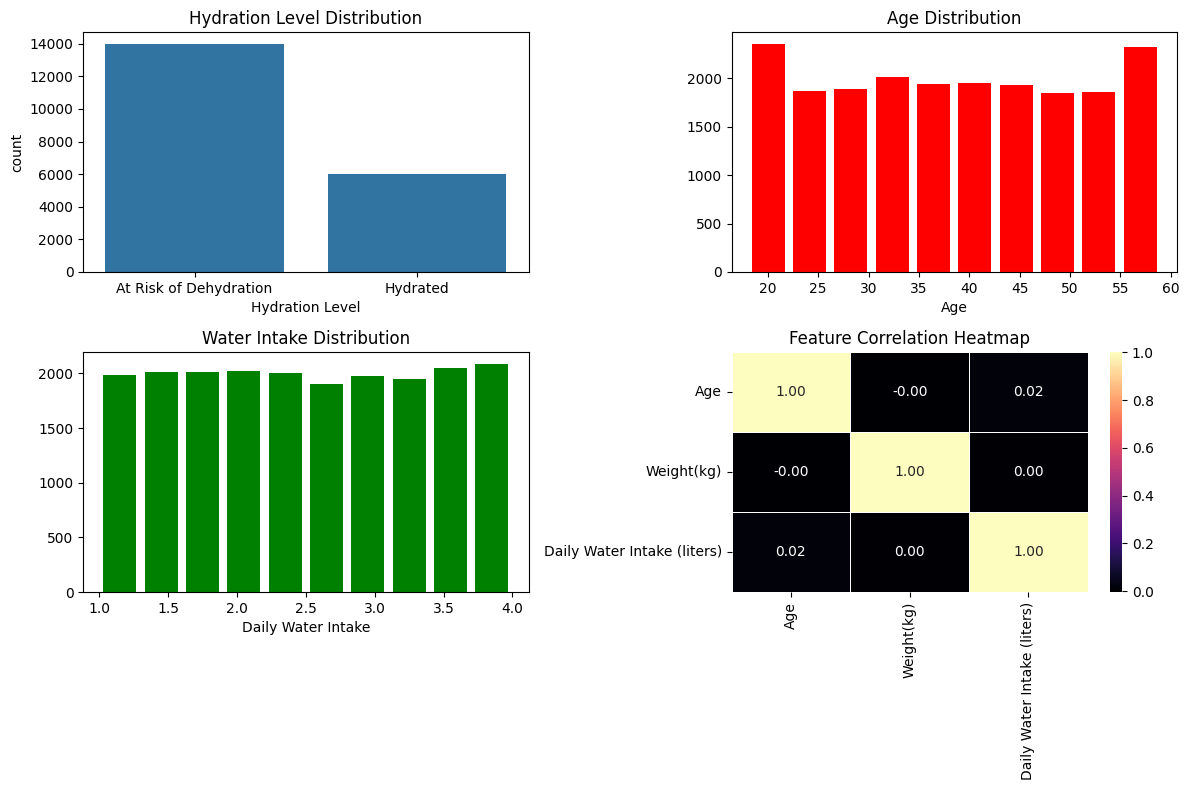

In [9]:
plt.figure(figsize=(12,8))

# 1 Hydration Distribution
plt.subplot(2,2,1)
sns.countplot(x='Hydration Level', data=df,width=0.8)
plt.title("Hydration Level Distribution")


# 2 Age Distribution
plt.subplot(2,2,2)
plt.hist(df['Age'], bins=10, color = "red",rwidth=0.8)
plt.title("Age Distribution")
plt.xlabel("Age")


# 3 Water Intake Distribution
plt.subplot(2,2,3)
plt.hist(df['Daily Water Intake (liters)'], bins=10, color = "green",rwidth=0.8)
plt.title("Water Intake Distribution")
plt.xlabel("Daily Water Intake")


# 4 Feature Correlation Heatmap
plt.subplot(2,2,4)
numeric_df = df.select_dtypes(include='number')
sns.heatmap(numeric_df.corr(), annot=True,cmap="magma",fmt=".2f",linewidths=0.5)
plt.title("Feature Correlation Heatmap")


plt.tight_layout()
plt.show()

### 6️⃣ Data Transformation

In [10]:
le = LabelEncoder()

# Columns to encode (categorical)
# Gender: Female=0, Male=1
# Physical Activity Level: High=0, Low=1, Moderate=2
# Hydration Level: At Risk of Dehydration=0, Hydrated=1

categorical_columns = df.select_dtypes(include=['object']).columns
print('Categorical columns to encode:', list(categorical_columns))

label_encoders = {}
for col in categorical_columns:
    label_encoders[col] = LabelEncoder()
    df[col] = label_encoders[col].fit_transform(df[col])
    print(f'{col} → classes: {list(label_encoders[col].classes_)}')

print()
df.head()

Categorical columns to encode: ['Gender', 'Physical Activity Level', 'Hydration Level']
Gender → classes: ['Female', 'Male']
Physical Activity Level → classes: ['High', 'Low', 'Moderate']
Hydration Level → classes: ['At Risk of Dehydration', 'Hydrated']



,Age,Gender,Weight(kg),Daily Water Intake (liters),Physical Activity Level,Hydration Level
0,43,0,93.45,1.64,2,0
1,43,1,78.15,3.51,1,1
2,56,0,80.82,2.96,1,1
3,45,1,98.33,3.58,1,1
4,22,0,86.86,2.59,0,0


### 7️⃣ Feature Scaling

In [11]:
# Columns to scale (continuous numerical only)
scale_cols = ['Weight(kg)', 'Daily Water Intake (liters)']

# Columns NOT to scale
no_scale_cols = ['Age', 'Gender', 'Physical Activity Level']

scaler = StandardScaler()
df[scale_cols] = scaler.fit_transform(df[scale_cols])

print('✅ Scaling applied to:', scale_cols)
print('⛔ Not scaled:', no_scale_cols)
print()
df.head()

✅ Scaling applied to: ['Weight(kg)', 'Daily Water Intake (liters)']
⛔ Not scaled: ['Age', 'Gender', 'Physical Activity Level']



,Age,Gender,Weight(kg),Daily Water Intake (liters),Physical Activity Level,Hydration Level
0,43,0,1.332830,-0.989085,2,0
1,43,1,0.367107,1.158789,1,1
2,56,0,0.535635,0.527061,1,1
3,45,1,1.640851,1.239191,1,1
4,22,0,0.916875,0.102081,0,0


### 8️⃣ Handle Class Imbalance with SMOTE

In [12]:
x = df.drop('Hydration Level', axis=1)
y = df['Hydration Level']

print(x.shape)
print(y.shape)

(20000, 5)
(20000,)


  Minority class ratio: 30.00%

⚠️  Imbalanced dataset detected — applying SMOTE...

Class distribution AFTER SMOTE:
Hydration Level
0    14000
1    14000
Name: count, dtype: int64


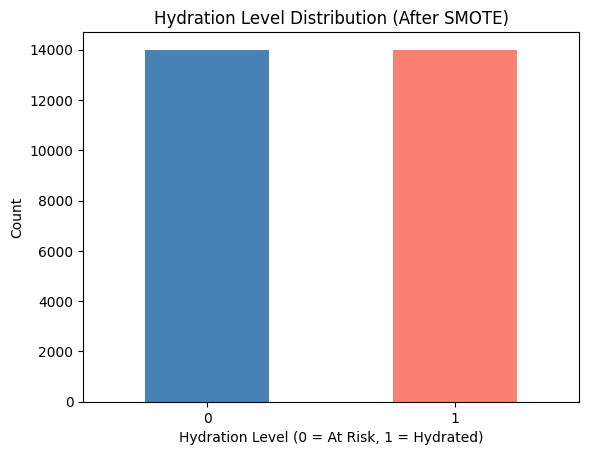

In [13]:
# Check imbalance (threshold: minority class < 40% of dataset)
min_class_ratio = y.value_counts().min() / len(y)
print(f'  Minority class ratio: {min_class_ratio:.2%}')

if min_class_ratio < 0.40:
    print('\n⚠️  Imbalanced dataset detected — applying SMOTE...')
    smote = SMOTE(random_state=42)
    x, y = smote.fit_resample(x, y)
    print('\nClass distribution AFTER SMOTE:')
    print(pd.Series(y).value_counts())
else:
    print('\n✅ Dataset is balanced — SMOTE not required.')

# Plot after SMOTE
pd.Series(y).value_counts().plot(kind='bar', color=['steelblue', 'salmon'])
plt.title('Hydration Level Distribution (After SMOTE)')
plt.xlabel('Hydration Level (0 = At Risk, 1 = Hydrated)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

### 9️⃣ Train Test Split

In [14]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

print('Training set size  :', x_train.shape)
print('Testing set size   :', x_test.shape)
print('Features           :', list(x.columns))

Training set size  : (22400, 5)
Testing set size   : (5600, 5)
Features           : ['Age', 'Gender', 'Weight(kg)', 'Daily Water Intake (liters)', 'Physical Activity Level']


### 🔟 Model 1 — Logistic Regression

In [15]:
lr= LogisticRegression(random_state=42, max_iter=1000)
lr.fit(x_train, y_train)
lr_pred = lr.predict(x_test)
lr_accuracy = accuracy_score(y_test, lr_pred)

print('Logistic Regression Accuracy:', round(lr_accuracy * 100, 2), '%')
print()
print(classification_report(y_test, lr_pred, target_names=['At Risk of Dehydration', 'Hydrated']))

Logistic Regression Accuracy: 75.91 %

                        precision    recall  f1-score   support

At Risk of Dehydration       0.76      0.73      0.75      2728
              Hydrated       0.76      0.78      0.77      2872

              accuracy                           0.76      5600
             macro avg       0.76      0.76      0.76      5600
          weighted avg       0.76      0.76      0.76      5600



### 1️⃣1️⃣ Model 2 — Random Forest

In [16]:
rf = RandomForestClassifier(random_state=42)
rf.fit(x_train, y_train)
rf_pred = rf.predict(x_test)
rf_accuracy = accuracy_score(y_test, rf_pred)

print('Random Forest Accuracy:', round(rf_accuracy * 100, 2), '%')
print()
print(classification_report(y_test, rf_pred, target_names=['At Risk of Dehydration', 'Hydrated']))

Random Forest Accuracy: 78.84 %

                        precision    recall  f1-score   support

At Risk of Dehydration       0.80      0.76      0.78      2728
              Hydrated       0.78      0.82      0.80      2872

              accuracy                           0.79      5600
             macro avg       0.79      0.79      0.79      5600
          weighted avg       0.79      0.79      0.79      5600



### 1️⃣2️⃣ Model 3 — XGBoost

In [17]:
xgb = XGBClassifier(eval_metric='logloss', random_state=42)
xgb.fit(x_train, y_train)
xgb_pred = xgb.predict(x_test)
xgb_accuracy = accuracy_score(y_test, xgb_pred)

print('XGBoost Accuracy:', round(xgb_accuracy * 100, 2), '%')
print()
print(classification_report(y_test, xgb_pred, target_names=['At Risk of Dehydration', 'Hydrated']))

XGBoost Accuracy: 76.59 %

                        precision    recall  f1-score   support

At Risk of Dehydration       0.78      0.73      0.75      2728
              Hydrated       0.76      0.80      0.78      2872

              accuracy                           0.77      5600
             macro avg       0.77      0.77      0.77      5600
          weighted avg       0.77      0.77      0.77      5600



### 1️⃣3️⃣ Model 4 — Gradient Boosting

In [18]:
gb_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42)
gb_model.fit(x_train, y_train)
gb_model_pred = gb_model.predict(x_test)
gb_model_accuracy = accuracy_score(y_test, gb_model_pred)

print('Gradient Boosting Accuracy:', round(gb_model_accuracy * 100, 2), '%')
print()
print(classification_report(y_test, gb_model_pred, target_names=['At Risk of Dehydration', 'Hydrated']))


Gradient Boosting Accuracy: 76.25 %

                        precision    recall  f1-score   support

At Risk of Dehydration       0.77      0.73      0.75      2728
              Hydrated       0.75      0.80      0.77      2872

              accuracy                           0.76      5600
             macro avg       0.76      0.76      0.76      5600
          weighted avg       0.76      0.76      0.76      5600



### 1️⃣4️⃣ Model Comparison

In [19]:
model_accuracies = {
    'Logistic Regression': lr_accuracy,
    'Random Forest': rf_accuracy,
    'XGBoost': xgb_accuracy,
    'Gradient Boosting': gb_model_accuracy}

results = pd.DataFrame({
    'Model': list(model_accuracies.keys()),
    'Accuracy': list(model_accuracies.values())
}).sort_values('Accuracy', ascending=False).reset_index(drop=True)

print('Model Accuracies:')
for _, row in results.iterrows():
    print(f"{row['Model']:<25} : {round(row['Accuracy']*100, 2)} %")

Model Accuracies:
Random Forest             : 78.84 %
XGBoost                   : 76.59 %
Gradient Boosting         : 76.25 %
Logistic Regression       : 75.91 %


### 1️⃣5️⃣ Model Performance Graph

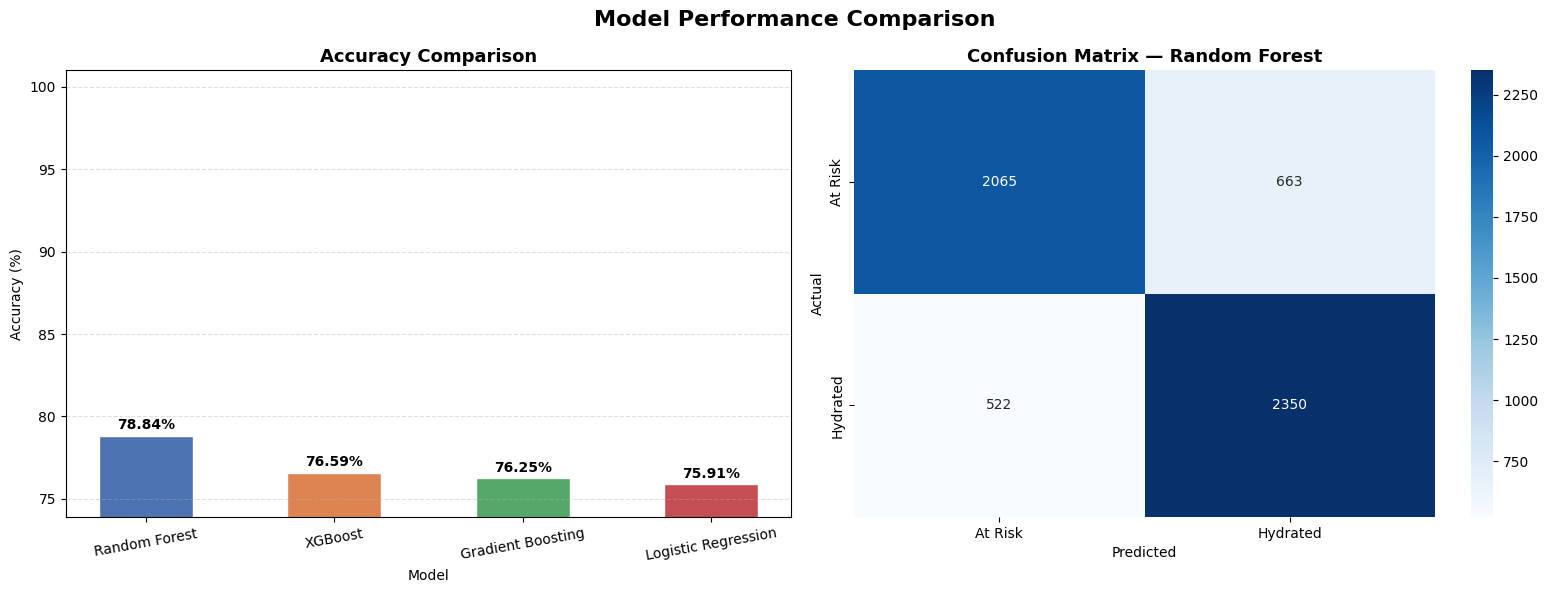

In [20]:
models_list = list(model_accuracies.keys())
preds = [lr_pred, rf_pred, xgb_pred,gb_model_pred]
bar_colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Model Performance Comparison', fontsize=16, fontweight='bold')

# --- Plot 1: Accuracy Bar Chart ---
bars = axes[0].bar(results['Model'], results['Accuracy'] * 100,
                   color=bar_colors, edgecolor='white', width=0.5)
axes[0].set_ylim(min(results['Accuracy'] * 100) - 2, 101)
axes[0].set_title('Accuracy Comparison', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Model')
axes[0].set_ylabel('Accuracy (%)')
axes[0].grid(axis='y', linestyle='--', alpha=0.4)
axes[0].tick_params(axis='x', rotation=10)
for bar in bars:
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.2,
                 f'{bar.get_height():.2f}%',
                 ha='center', va='bottom', fontsize=10, fontweight='bold')

# --- Plot 2: Confusion Matrix of Best Model ---
best_model_name = results.iloc[0]['Model']
best_pred = preds[models_list.index(best_model_name)]
cm = confusion_matrix(y_test, best_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['At Risk', 'Hydrated'],
            yticklabels=['At Risk', 'Hydrated'])
axes[1].set_title(f'Confusion Matrix — {best_model_name}', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

### 1️⃣6️⃣ Select Best Model

In [21]:
best_model_name = max(model_accuracies, key=model_accuracies.get)
best_accuracy   = model_accuracies[best_model_name]

model_map = {
    'Logistic Regression': lr,
    'Random Forest':       rf,
    'XGBoost':             xgb,
    'Gradient Boosting': gb_model
}

best_model_obj = model_map[best_model_name]

print(f'🏆 Best Model  : {best_model_name}')
print(f'   Accuracy    : {round(best_accuracy * 100, 2)} %')



🏆 Best Model  : Random Forest
   Accuracy    : 78.84 %


### 1️⃣7️⃣ Save the Best Model

In [22]:
with open('best_model.pkl', 'wb') as f:
    pickle.dump(best_model_obj, f)

with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print()
print('✅ best_model.pkl saved')
print('✅ scaler.pkl saved')


✅ best_model.pkl saved
✅ scaler.pkl saved


### 1️⃣8️⃣ Model Deployment (using Gradio)

In [23]:
import gradio as gr
import numpy as np
import pickle

# Load saved artifacts
model  = pickle.load(open('best_model.pkl', 'rb'))
scaler = pickle.load(open('scaler.pkl', 'rb'))

# ─── Encoding maps (must match LabelEncoder fit order) ──────
# Gender              : Female=0, Male=1
# Physical Activity   : High=0, Low=1, Moderate=2
# ────────────────────────────────────────────────────────────

gender_map   = {'Female': 0, 'Male': 1}
activity_map = {'High': 0, 'Low': 1, 'Moderate': 2}
label_map    = {0: '🔴 At Risk of Dehydration', 1: '🟢 Hydrated'}


def predict_hydration(age, gender, weight, water_intake, activity):
    """
    Pipeline:
      1. Encode categorical inputs (Gender, Physical Activity Level)
      2. Scale only continuous features (Weight, Water Intake, Urine Color
         — Urine Color is not a user input, so we pass 0 as placeholder for
         the scaler slot; the model was trained without it at prediction time)
      3. Assemble feature vector in training order and predict
    """
    gender_enc   = gender_map[gender]
    activity_enc = activity_map[activity]

    # Scale continuous columns: [Weight(kg), Daily Water Intake (liters)]
    # not collected at deployment time
    
    scaled = scaler.transform([[weight, water_intake]])
    weight_s = scaled[0][0]
    water_s  = scaled[0][1]
    

    # Feature order: Age, Gender, Weight(kg), Daily Water Intake (liters),
    #                Physical Activity Level
    features = np.array([[age, gender_enc, weight_s, water_s, activity_enc]])

    prediction = model.predict(features)[0]
    prob = None
    if hasattr(model, 'predict_proba'):
        prob = model.predict_proba(features)[0][prediction]

    result = label_map[prediction]
    if prob is not None:
        result += f'  (Confidence: {round(prob * 100, 1)}%)'
    return result


app = gr.Interface(
    fn=predict_hydration,
    inputs=[
        gr.Slider(minimum=18, maximum=59, step=1,  label='Age'),
        gr.Radio(['Male', 'Female'],                label='Gender'),
        gr.Slider(minimum=45, maximum=100, step=0.5, label='Weight (kg)'),
        gr.Slider(minimum=0.5, maximum=5.0, step=0.1, label='Daily Water Intake (liters)'),
        gr.Radio(['Low', 'Moderate', 'High'],       label='Physical Activity Level'),
    ],
    outputs=gr.Textbox(label='Prediction'),
    title='💧 Hydration Level Predictor',
    description=(
        'Enter your details below to predict your hydration status.'
    ),
    theme=gr.themes.Soft(),
    flagging_mode='never'
)

app.launch(share=True)

* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://1c8f27bcc142493a08.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
